# Customer Churn & Retention Analysis
## Telecom Customer Analytics Project
### Libraries Used:
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Executive Summary

This project analyzes telecom customer churn behavior
using SQL, Python, and Power BI.

The goal is to identify:
- Why customers leave
- High-risk churn customers
- Important churn factors
- Business strategies for retention

## Problem Statement

Customer churn is one of the major challenges
for telecom companies.

The objective of this project is to analyze
customer behavior and identify the main reasons
behind customer churn.

## Dataset Overview

The dataset contains customer information such as:
- Demographics
- Contract details
- Internet services
- Charges
- Support services
- Churn status

In [1]:
## 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Done")

Done


In [2]:
## 2. LOAD DATASET
df=pd.read_csv(r"C:\Users\Ashu\OneDrive\Desktop\PROJECTS GITHUB\COMBINED PROJECTS\Customer Churn & Retention Analysis\Python Data\Churn_Raw.csv")

## Data Understanding

Understanding the dataset structure,
columns, and customer information.

In [63]:
## 3. BASIC DATA UNDERSTANDING

print(df.head())
df.info()
print(df.tail())
print("Dataset Shape:", df.shape)
print(df.columns)
df.describe()

   CustomerID  Age  Gender  Tenure  MonthlyCharges    ContractType  \
0           1   49    Male       4           88.35  Month-to-Month   
1           2   43    Male       0           36.67  Month-to-Month   
2           3   51  Female       2           63.79  Month-to-Month   
3           4   60  Female       8          102.34        One-Year   
4           5   42    Male      32           69.01  Month-to-Month   

  InternetService  TotalCharges TechSupport Churn  ChurnFlag TenureGroup  \
0     Fiber Optic        353.40         Yes   Yes          1         New   
1     Fiber Optic          0.00         Yes   Yes          1         NaN   
2     Fiber Optic        127.58          No   Yes          1         New   
3             DSL        818.72         Yes   Yes          1         New   
4             NaN       2208.32          No   Yes          1   2-4 Years   

  ChargeCategory  AnnualCharges  
0           High        1060.20  
1         Medium         440.04  
2         Medium    

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,ChurnFlag,AnnualCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060,0.883000,892.695480
std,288.819436,9.797741,18.89257,25.712083,1571.755048,0.321581,308.544997
min,1.000000,12.000000,0.00000,30.000000,0.000000,0.000000,360.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500,1.000000,628.290000
50%,500.500000,45.000000,13.00000,74.060000,872.870000,1.000000,888.720000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000,1.000000,1153.230000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000,1.000000,1439.520000


## Data Cleaning

Performed:
- Missing value handling
- Duplicate removal
- Data type conversion
- Feature engineering

In [4]:
## 4. CHECK MISSING VALUES
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [5]:
## 5. CHECK DUPLICATE RECORDS
print(df.drop_duplicates(inplace=True))

None


In [6]:
## 6. DATA CLEANING

# Convert TotalCharges into numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.info()

# Fill missing numeric values
df.fillna(df.median(numeric_only=True),inplace=True)
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [7]:
## 7. UNIQUE VALUES
df.nunique()

CustomerID         1000
Age                  57
Gender                2
Tenure               87
MonthlyCharges      935
ContractType          3
InternetService       2
TotalCharges        943
TechSupport           2
Churn                 2
dtype: int64

In [8]:
## 8. CHURN DISTRIBUTION
df['Churn'].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

## Feature Engineering

Created:
- ChurnFlag
- TenureGroup
- ChargeCategory
- AnnualCharges

In [9]:
## 9. FEATURE ENGINEERING
# Convert Churn into numeric
df['ChurnFlag']=df['Churn'].map({
    'Yes':1,
    'No':0
})

# Tenure Groups
df['TenureGroup']=pd.cut(
    df['Tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', '1-2 Years', '2-4 Years', '4+ Years']
)
df['ChargeCategory'] = pd.cut(
        df['MonthlyCharges'],
    bins=[0,35,70,120],
    labels=['Low','Medium','High']
)

# Annual Charges
df['AnnualCharges']=df['MonthlyCharges']*12
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn,ChurnFlag,TenureGroup,ChargeCategory,AnnualCharges
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes,1,New,High,1060.20
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes,1,NaN,Medium,440.04
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes,1,New,Medium,765.48
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes,1,New,High,1228.08
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes,1,2-4 Years,Medium,828.12


In [10]:
## 10. SAVE CLEANED DATASET
df.to_csv(r"C:\Users\Ashu\OneDrive\Desktop\PROJECTS GITHUB\COMBINED PROJECTS\Customer Churn & Retention Analysis\Python Data\churned_cleaned.csv",index=False)

## Exploratory Data Analysis (EDA)

Visual analysis was performed to identify
customer churn patterns and trends.

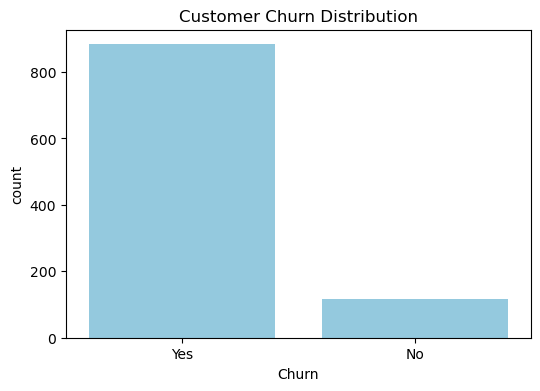

Key Insight: High customer churn count is a critical business alert that requires immediate retention strategies.


In [53]:
## 11. EXPLORATORY DATA ANALYSIS (EDA)
# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn',data=df,color='skyblue')
plt.title('Customer Churn Distribution')
plt.show()
print("""Key Insight: High customer churn count is a critical business alert that requires immediate retention strategies.""")

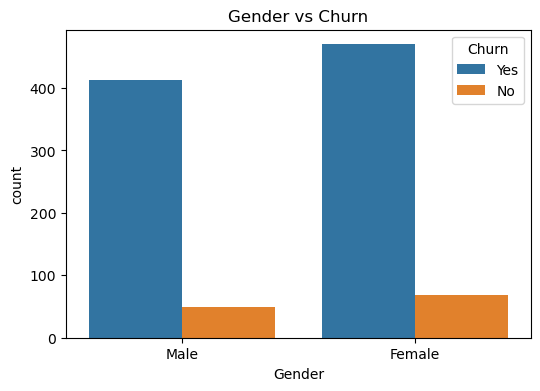

Key Insight: Churn rates are almost identical across genders, showing that gender does not influence a customer's decision to leave.


In [55]:
#Gender v/s Churn
plt.figure(figsize=(6,4))
sns.countplot(x='Gender',hue='Churn',data=df)
plt.title('Gender vs Churn')
plt.show()
print("""Key Insight: Churn rates are almost identical across genders, showing that gender does not influence a customer's decision to leave.""")

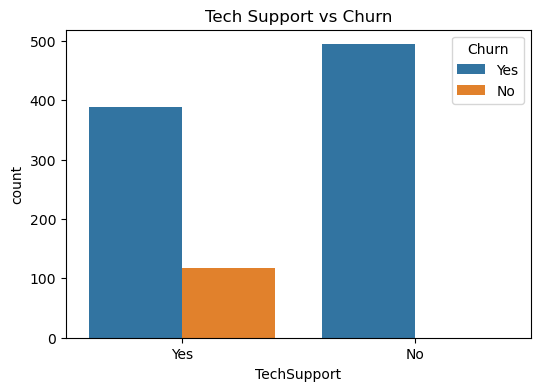

Key Insight: Customers with no technical support show high churn, proving that quick tech assistance directly keeps customers loyal.


In [56]:
# Tech Support v/s Churn
plt.figure(figsize=(6,4))
sns.countplot(x='TechSupport',hue='Churn',data=df)
plt.title('Tech Support vs Churn')
plt.show()
print("""Key Insight: Customers with no technical support show high churn, proving that quick tech assistance directly keeps customers loyal.""")

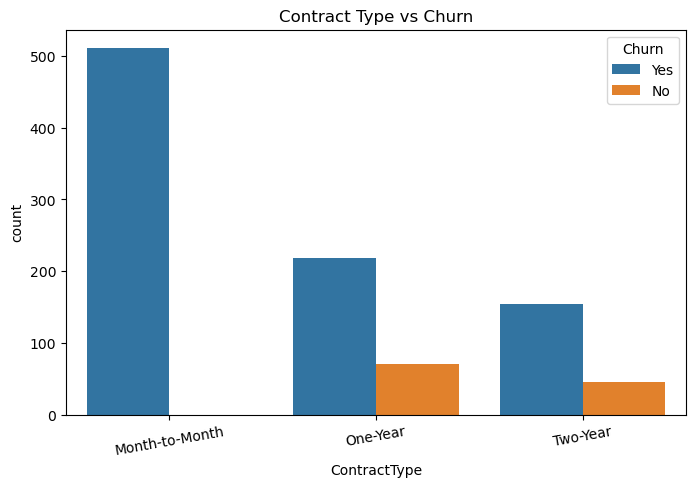

Key Insight: Month-to-month contract users have the highest churn rate, whereas long-term contracts ensure much better customer retention.


In [57]:
# Contract Type v/s Churn
plt.figure(figsize=(8,5))
sns.countplot(x='ContractType',hue='Churn',data=df)
plt.xticks(rotation=10)
plt.title('Contract Type vs Churn')
plt.show()
print("""Key Insight: Month-to-month contract users have the highest churn rate, whereas long-term contracts ensure much better customer retention.""")

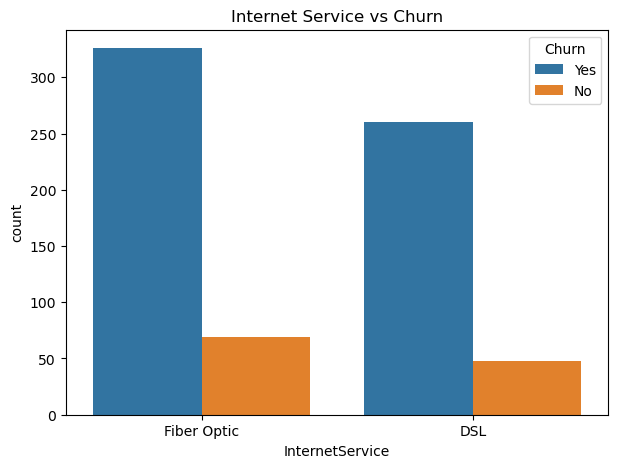

Key Insight: Fiber Optic users are leaving much faster than DSL users, indicating potential issues in service quality or high costs.


In [58]:
# Internet Service v/s Churn
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.title('Internet Service vs Churn')
plt.show()
print("""Key Insight: Fiber Optic users are leaving much faster than DSL users, indicating potential issues in service quality or high costs.""")

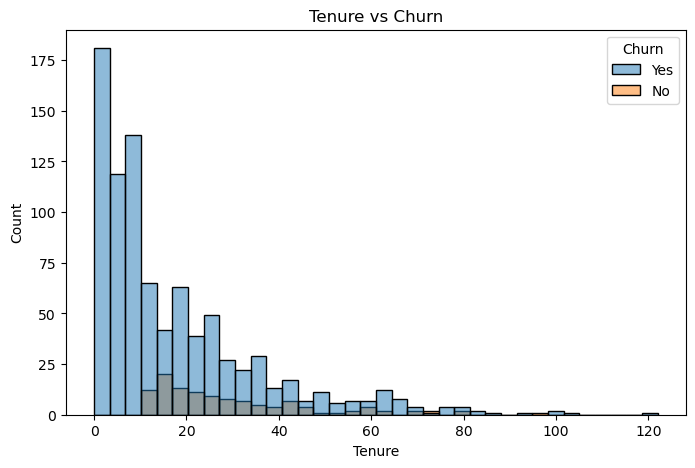

Key Insight: Most customer churn occurs during the first few months, highlighting the critical need for stronger early engagement.


In [59]:
# Tenure Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Tenure',hue='Churn',bins=36)
plt.title('Tenure vs Churn')
plt.show()
print("""Key Insight: Most customer churn occurs during the first few months, highlighting the critical need for stronger early engagement.""")

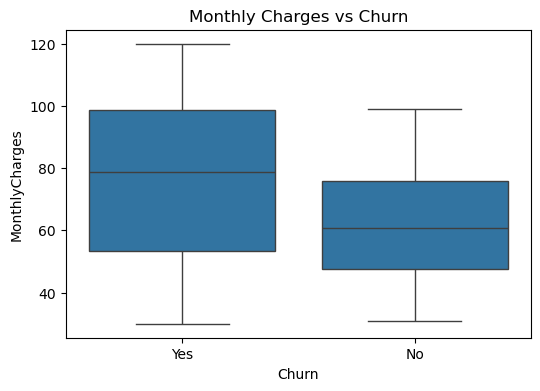

Key Insight: High monthly charges are directly causing customers to leave, while low-tier pricing plans show better customer loyalty.


In [60]:
# Monthly Charges v/s Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title('Monthly Charges vs Churn')
plt.show()
print("""Key Insight: High monthly charges are directly causing customers to leave, while low-tier pricing plans show better customer loyalty.""")

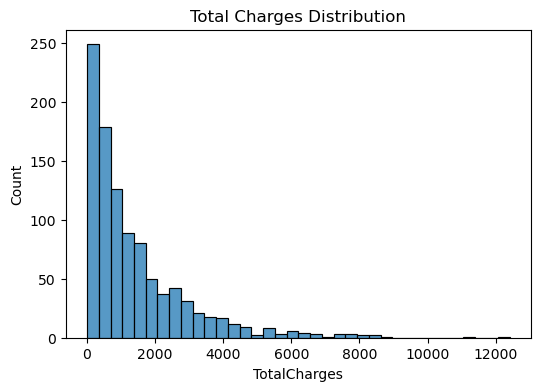

Key Insight: Total charges are skewed toward lower amounts, confirming that most customers leave early before spending much.


In [61]:
# Total Charges Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['TotalCharges'],bins=36)
plt.title('Total Charges Distribution')
plt.show()
print("""Key Insight: Total charges are skewed toward lower amounts, confirming that most customers leave early before spending much.""")

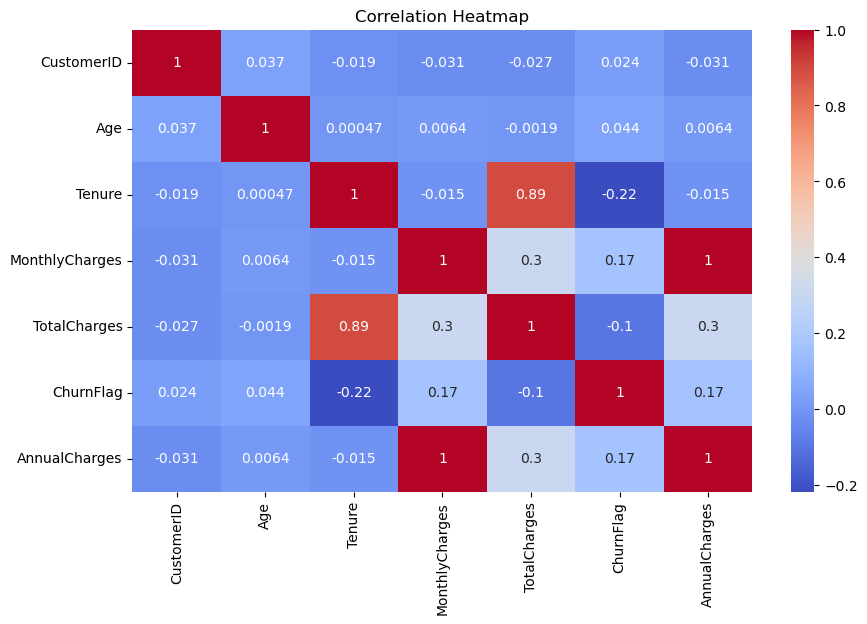

Key Insight: Monthly charges have a strong positive relationship with churn, while long tenure and tech support strongly prevent it.


In [62]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
print("""Key Insight: Monthly charges have a strong positive relationship with churn, while long tenure and tech support strongly prevent it.""")

In [20]:
## 12. GROUPBY ANALYSIS

# Average Monthly Charges by Churn
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [21]:
# Average Tenure by Churn
df.groupby('Churn')['Tenure'].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [22]:
# Contract Type Count
df.groupby('ContractType')['Churn'].value_counts()

ContractType    Churn
Month-to-Month  Yes      511
One-Year        Yes      218
                No        71
Two-Year        Yes      154
                No        46
Name: count, dtype: int64

In [23]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn,ChurnFlag,TenureGroup,ChargeCategory,AnnualCharges
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes,1,New,High,1060.20
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes,1,NaN,Medium,440.04
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes,1,New,Medium,765.48
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes,1,New,High,1228.08
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes,1,2-4 Years,Medium,828.12


## Machine Learning Model

Logistic Regression was used to predict
customer churn because churn prediction
is a binary classification problem.

In [24]:
## 13. MACHINE LEARNING MODELS
features=['Gender','Tenure','MonthlyCharges','ContractType','InternetService','TotalCharges','TechSupport']
X_encoded=pd.get_dummies(df[features],drop_first=True)
print(X_encoded.head().to_string(index=False))

 Tenure  MonthlyCharges  TotalCharges  Gender_Male  ContractType_One-Year  ContractType_Two-Year  InternetService_Fiber Optic  TechSupport_Yes
      4           88.35        353.40         True                  False                  False                         True             True
      0           36.67          0.00         True                  False                  False                         True             True
      2           63.79        127.58        False                  False                  False                         True            False
      8          102.34        818.72        False                   True                  False                        False             True
     32           69.01       2208.32         True                  False                  False                        False            False


In [25]:
## 14. DEFINE X AND y
X=X_encoded
y=df['ChurnFlag']

In [26]:
## 15. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)
print(X_train,X_test,y_train,y_test)

     Tenure  MonthlyCharges  TotalCharges  Gender_Male  ContractType_One-Year  \
541       0           40.68          0.00         True                  False   
440      94           89.57       8419.58         True                   True   
482      11           89.13        980.43         True                  False   
422      37           69.85       2584.45        False                  False   
778      18           91.43       1645.74        False                  False   
..      ...             ...           ...          ...                    ...   
106      10          119.90       1199.00         True                  False   
270       5           81.69        408.45        False                  False   
860      55           78.63       4324.65         True                  False   
435      12          117.13       1405.56        False                  False   
102      20           52.41       1048.20        False                  False   

     ContractType_Two-Year 

In [27]:
## 16. TRAIN LOGISTIC REGRESSION MODEL
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
## 17. PREDICTIONS
predictions=model.predict(X_test)

In [42]:
## 18. MODEL EVALUATION
accuracy=accuracy_score(y_test,predictions)
print("Model Accuracy:",accuracy)
print(classification_report(y_test,predictions))
cm=confusion_matrix(y_test,predictions)
print(cm)

Model Accuracy: 0.9433333333333334
              precision    recall  f1-score   support

           0       0.92      0.62      0.74        39
           1       0.95      0.99      0.97       261

    accuracy                           0.94       300
   macro avg       0.93      0.80      0.85       300
weighted avg       0.94      0.94      0.94       300

[[ 24  15]
 [  2 259]]


In [50]:
## 19. FEATURE IMPORTANCE
importance=pd.Series(model.coef_[0],index=X.columns)
print(importance.sort_values(ascending=False).head(10))

Gender_Male                    0.345087
MonthlyCharges                 0.014667
TotalCharges                   0.000343
Tenure                        -0.081924
InternetService_Fiber Optic   -0.261424
ContractType_Two-Year         -3.381816
ContractType_One-Year         -3.722066
TechSupport_Yes               -3.938027
dtype: float64


## Model Results

The Logistic Regression model achieved
good prediction accuracy for churn prediction.

## Business Recommendations

- Offer discounts on yearly contracts
- Improve onboarding for new customers
- Provide loyalty rewards
- Improve tech support services
- Reduce customer complaints